# DQN: from a Q-table to a neural network

This notebook builds a small Deep Q-Network (DQN) agent with PyTorch and Gymnasium.

DQN approximates action values with a network $Q_\theta(s,a)$. It is an **off-policy** algorithm: an $\varepsilon$-greedy behavior policy collects experience, while learning uses a greedy bootstrap target. Two ideas make this practical:

- a **replay buffer** breaks correlations by sampling older transitions;
- a delayed **target network** makes bootstrap targets change more slowly.

In [ ]:
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

ENV_ID = "CartPole-v1"
TOTAL_TIMESTEPS = 50_000
LEARNING_RATE = 3e-4
GAMMA = 0.99
BUFFER_SIZE = 10_000
BATCH_SIZE = 64
LEARNING_STARTS = 1_000
TRAIN_FREQ = 4
TARGET_UPDATE_INTERVAL = 500
EPSILON_START = 1.0
EPSILON_END = 0.01
EXPLORATION_STEPS = 10_000
MAX_GRAD_NORM = 10.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
env = gym.make(ENV_ID)
observation_dim = int(np.prod(env.observation_space.shape))
action_dim = env.action_space.n
print(f"device={device}, observations={observation_dim}, actions={action_dim}")

device=cuda, observations=4, actions=2


## 1. Create online and target networks

The online network produces one Q-value per discrete action. The target network begins as an exact copy and is not optimized directly. Its parameters are periodically replaced with the online parameters:

$$\theta^- \leftarrow \theta.$$

In [2]:
class QNetwork(nn.Module):
    def __init__(self, observation_dim, action_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(observation_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, observations):
        return self.layers(observations.flatten(start_dim=1))


q_network = QNetwork(observation_dim, action_dim).to(device)
target_network = QNetwork(observation_dim, action_dim).to(device)
target_network.load_state_dict(q_network.state_dict())
target_network.eval()
optimizer = torch.optim.Adam(q_network.parameters(), lr=LEARNING_RATE)

## 2. Act with an epsilon-greedy policy

At step $t$, choose a uniformly random action with probability $\varepsilon_t$ and otherwise choose $\arg\max_a Q_\theta(s_t,a)$. Evaluation always uses the greedy branch.

Network inference for action selection should not build a gradient graph.

In [3]:
def epsilon_at(step):
    fraction = np.clip(step / EXPLORATION_STEPS, 0.0, 1.0)
    return EPSILON_START + fraction * (EPSILON_END - EPSILON_START)


def select_action(observation, step, deterministic=False):
    """Return an epsilon-greedy action from the online network."""
    obs = torch.as_tensor(observation, device=device, dtype=torch.float32).unsqueeze(0)
    q_values = q_network(obs)
    if deterministic or np.random.rand() > epsilon_at(step):
        return int(torch.argmax(q_values, dim=1).item())
    else:
        return int(np.random.randint(action_dim))

## 3. Store and sample experience

Each replay item is $(s_t,a_t,r_{t+1},s_{t+1},d_t)$. Here $d_t$ records only Gymnasium's `terminated` flag: a time-limit `truncated` transition ends the episode but still bootstraps because the underlying MDP did not terminate.

Uniform sampling produces tensors with a batch dimension. Actions are `long` indices; all other tensors use `float32`. The expected shapes are `(B, observation_dim)` for observations and `(B, 1)` for actions, rewards, and terminal flags.

In [4]:
replay_buffer = deque(maxlen=BUFFER_SIZE)


def add_transition(state, action, reward, next_states, terminated):
    replay_buffer.append(
        (
            np.asarray(state, dtype=np.float32),
            np.asarray(action, dtype=np.int64),
            np.asarray(reward, dtype=np.float32),
            np.asarray(next_states, dtype=np.float32),
            np.asarray(terminated, dtype=np.float32),
        )
    )


def sample_batch(batch_size):
    """Uniformly sample replay and return five tensors on device."""
    indices = np.random.choice(len(replay_buffer), batch_size, replace=False)
    transitions = [replay_buffer[idx] for idx in indices]
    states, actions, rewards, next_states, terminations = zip(*transitions)
    return (
        torch.as_tensor(np.asarray(states), device=device, dtype=torch.float32),
        torch.as_tensor(np.asarray(actions), device=device, dtype=torch.int64),
        torch.as_tensor(np.asarray(rewards), device=device, dtype=torch.float32),
        torch.as_tensor(np.asarray(next_states), device=device, dtype=torch.float32),
        torch.as_tensor(np.asarray(terminations), device=device, dtype=torch.float32),
    )

## 4. Compute the DQN loss and update the online network

For each sampled transition, vanilla DQN uses

$$
y_i=r_i+\gamma(1-d_i)\max_{a'}Q_{\theta^-}(s'_i,a')
$$

and compares it with the prediction for the action that was actually recorded:

$$q_i=Q_\theta(s_i,a_i).$$

The online network minimizes the mean Huber loss between $q_i$ and $y_i$. The target must be treated as a constant during backpropagation.

In [5]:
def train_step():
    states, actions, rewards, next_states, terminated = sample_batch(BATCH_SIZE)

    q_values = q_network(states).gather(1, actions.unsqueeze(-1)).squeeze(-1)
    next_q_values = target_network(next_states).max(1)[0]
    target_q_values = rewards + GAMMA * (1 - terminated) * next_q_values
    
    loss = nn.functional.huber_loss(q_values, target_q_values.detach())
    optimizer.zero_grad()
    loss.backward()
    
    torch.nn.utils.clip_grad_norm_(q_network.parameters(), MAX_GRAD_NORM)
    optimizer.step()
    
    return loss.item()

## 5. Connect collection and learning

The loop collects one transition per environment step. Learning starts only after `LEARNING_STARTS`, then runs every `TRAIN_FREQ` steps. The target network receives a hard update every `TARGET_UPDATE_INTERVAL` steps.

A hard update copies the complete online-network state into the target network.

In [6]:
def train(total_timesteps):
    episode_returns = []
    losses = []
    episode_return = 0.0
    state, _ = env.reset()

    for step in range(1, total_timesteps + 1):
        action = select_action(state, step - 1)
        next_state, reward, terminated, truncated, _ = env.step(action)
        add_transition(state, action, reward, next_state, terminated)
        episode_return += reward

        if step >= LEARNING_STARTS and step % TRAIN_FREQ == 0 and len(replay_buffer) >= BATCH_SIZE:
            losses.append(train_step())

        if step % TARGET_UPDATE_INTERVAL == 0:
            target_network.load_state_dict(q_network.state_dict())

        if terminated or truncated:
            episode_returns.append(episode_return)
            episode_return = 0.0
            state, _ = env.reset()
        else:
            state = next_state
            
        print(f"\rStep {step}/{total_timesteps} | Episodes: {len(episode_returns)} | Episode Return: {episode_return:.2f} | Epsilon: {epsilon_at(step):.3f}", end="")

    env.close()
    return episode_returns, losses


episode_returns, losses = train(TOTAL_TIMESTEPS)
print(f"\nTrained for {len(episode_returns)} episodes and {len(losses)} updates.")

Step 20000/20000 | Episodes: 260 | Episode Return: 135.00 | Epsilon: 0.010
Trained for 260 episodes and 4751 updates.


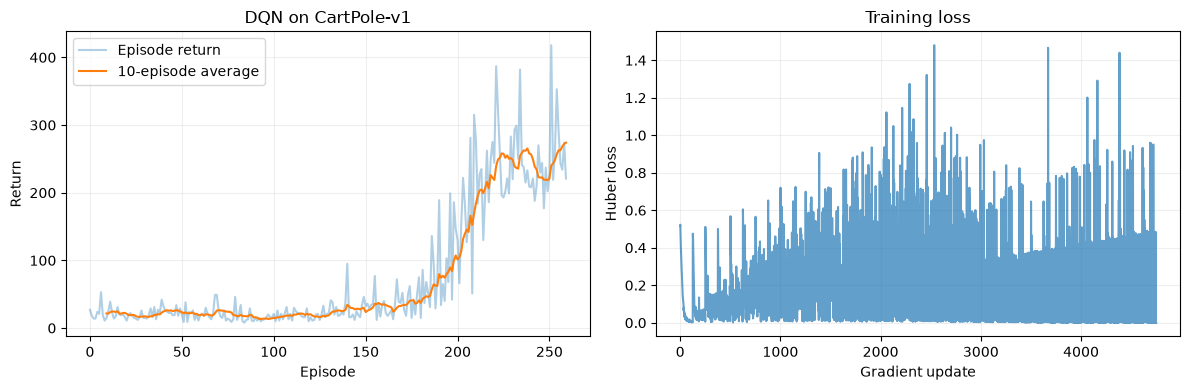

In [7]:
returns = np.asarray(episode_returns)
window = min(10, len(returns))
moving_average = np.convolve(returns, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(returns, alpha=0.35, label="Episode return")
axes[0].plot(np.arange(window - 1, len(returns)), moving_average, label=f"{window}-episode average")
axes[0].set(xlabel="Episode", ylabel="Return", title=f"DQN on {ENV_ID}")
axes[0].legend()
axes[1].plot(losses, alpha=0.7)
axes[1].set(xlabel="Gradient update", ylabel="Huber loss", title="Training loss")
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Evaluate the greedy policy

Evaluation disables exploration and does not render, so this cell works in headless notebook environments.

In [ ]:
env = gym.make(ENV_ID, render_mode="human")
episode_returns = []

for episode in range(5):
    state, _ = env.reset()
    episode_return = 0.0
    for step in range(1000):
        action = select_action(state, step=0, deterministic=True)
        state, reward, terminated, truncated, _ = env.step(action)
        episode_return += reward
        print(f"Episode {episode + 1}: step={step + 1}, return={episode_return:.1f}", end="\r")
        if terminated or truncated:
            break
    episode_returns.append(episode_return)
    print()

env.close()
print(f"Mean return: {np.mean(episode_returns):.1f} +/- {np.std(episode_returns):.1f}")

Episode 1: step=220, return=220.0
Episode 2: step=241, return=241.0
Episode 3: step=242, return=242.0
Episode 4: step=233, return=233.0
Episode 5: step=224, return=224.0
Mean return: 232.0 +/- 8.8
